In [1]:
#Import required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
#Load the dataset
df=pd.read_csv('Logistics_Shipments.csv')

In [2]:
#Check the shape of the dataset (number of rows and columns)
df.shape

(1400, 13)

In [3]:
# Check data types of each column
df.dtypes

shipment_id        object
ship_date          object
origin             object
destination        object
carrier            object
service_level      object
item_category      object
distance_km       float64
weight_kg         float64
promised_date      object
delivered_date     object
shipping_cost     float64
damaged_flag        int64
dtype: object

In [4]:
#convert date column from object type to datetime format
df['ship_date']=pd.to_datetime(df['ship_date'])
df['promised_date']=pd.to_datetime(df['promised_date'])
df['delivered_date']=pd.to_datetime(df['delivered_date'])

In [5]:
#Display first 5 row of dataset
df.head()

,shipment_id,ship_date,origin,destination,carrier,service_level,item_category,distance_km,weight_kg,promised_date,delivered_date,shipping_cost,damaged_flag
0,SHP500000,2025-08-16,Mumbai,Nagpur,DTDC,Express,Clothing,1393.2,2.00,2025-08-21,2025-08-21,291.46,0
1,SHP500001,2024-12-03,Kolkata,Kochi,Delhivery,Standard,Clothing,943.1,2.40,2024-12-09,NaT,175.45,0
2,SHP500002,2025-07-24,Delhi,Pune,BlueDart,Standard,HomeDecor,623.4,4.37,2025-07-28,2025-07-29,199.12,0
3,SHP500003,2025-03-27,Ahmedabad,Kochi,XpressBees,Standard,Electronics,160.8,3.10,2025-03-29,2025-03-29,130.36,0
4,SHP500004,2025-11-01,Chennai,Surat,BlueDart,Standard,Pharmacy,1767.9,4.26,2025-11-07,2025-11-10,287.93,0


In [6]:
#Display last 5 rows of the dataset
df.tail()

,shipment_id,ship_date,origin,destination,carrier,service_level,item_category,distance_km,weight_kg,promised_date,delivered_date,shipping_cost,damaged_flag
1395,SHP501395,2025-12-24,Hyderabad,Surat,EcomExpress,Express,Electronics,1036.7,1.41,2025-12-29,2025-12-29,248.19,0
1396,SHP501396,2025-12-09,Hyderabad,Gurugram,EcomExpress,Standard,Groceries,1964.3,1.08,2025-12-15,2025-12-17,224.14,0
1397,SHP501397,2024-11-20,Delhi,Indore,Delhivery,Standard,Pharmacy,1778.5,0.38,2024-11-26,2024-11-26,191.78,0
1398,SHP501398,2025-11-27,Kolkata,Kochi,BlueDart,Standard,HomeDecor,2096.9,5.54,2025-12-03,2025-12-04,346.25,0
1399,SHP501399,2025-05-31,Ahmedabad,Indore,BlueDart,Express,Pharmacy,818.7,4.76,2025-06-05,2025-06-05,314.50,0


In [7]:
#summary statistics for numerical columns
df.describe()

,ship_date,distance_km,weight_kg,promised_date,delivered_date,shipping_cost,damaged_flag
count,1400,1400.000000,1400.000000,1400,1379,1400.000000,1400.000000
mean,2025-05-05 17:16:48,1147.284429,2.897086,2025-05-10 09:49:22.285714176,2025-05-11 10:59:57.389412608,246.981257,0.042143
min,2024-09-01 00:00:00,30.800000,0.030000,2024-09-05 00:00:00,2024-09-06 00:00:00,60.840000,0.000000
25%,2025-01-03 00:00:00,608.900000,1.390000,2025-01-08 18:00:00,2025-01-09 00:00:00,187.887500,0.000000
50%,2025-05-10 00:00:00,1178.750000,2.410000,2025-05-14 00:00:00,2025-05-17 00:00:00,242.245000,0.000000
75%,2025-09-03 06:00:00,1694.225000,3.950000,2025-09-08 00:00:00,2025-09-09 00:00:00,301.907500,0.000000
max,2025-12-31 00:00:00,2199.700000,13.330000,2026-01-06 00:00:00,2026-01-08 00:00:00,646.660000,1.000000
std,NaN,627.351770,1.981755,NaN,NaN,85.236398,0.200987


In [8]:
#Check the number of missing values in each column of the dataset
df.isnull().sum()

shipment_id        0
ship_date          0
origin             0
destination        0
carrier            0
service_level      0
item_category      0
distance_km        0
weight_kg          0
promised_date      0
delivered_date    21
shipping_cost      0
damaged_flag       0
dtype: int64

In [9]:
#Remove row with missing Delivery Date
df=df.dropna(subset=['delivered_date'])

In [10]:
#verify missing values are removed or not
df.isnull().sum()

shipment_id       0
ship_date         0
origin            0
destination       0
carrier           0
service_level     0
item_category     0
distance_km       0
weight_kg         0
promised_date     0
delivered_date    0
shipping_cost     0
damaged_flag      0
dtype: int64

In [11]:
#check for duplicate records
df.duplicated().sum()

np.int64(0)

In [12]:
#Summary statistics to identify potential anomalies
df.select_dtypes(include=np.number).describe()

,distance_km,weight_kg,shipping_cost,damaged_flag
count,1379.000000,1379.000000,1379.000000,1379.000000
mean,1145.640609,2.898028,246.654445,0.042059
std,628.260818,1.987469,85.144882,0.200798
min,30.800000,0.030000,60.840000,0.000000
25%,602.950000,1.390000,187.845000,0.000000
50%,1169.900000,2.410000,242.150000,0.000000
75%,1694.100000,3.950000,301.650000,0.000000
max,2199.700000,13.330000,646.660000,1.000000


In [13]:
#final dataset verification after cleaning
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
Index: 1379 entries, 0 to 1399
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   shipment_id     1379 non-null   object        
 1   ship_date       1379 non-null   datetime64[ns]
 2   origin          1379 non-null   object        
 3   destination     1379 non-null   object        
 4   carrier         1379 non-null   object        
 5   service_level   1379 non-null   object        
 6   item_category   1379 non-null   object        
 7   distance_km     1379 non-null   float64       
 8   weight_kg       1379 non-null   float64       
 9   promised_date   1379 non-null   datetime64[ns]
 10  delivered_date  1379 non-null   datetime64[ns]
 11  shipping_cost   1379 non-null   float64       
 12  damaged_flag    1379 non-null   int64         
dtypes: datetime64[ns](3), float64(3), int64(1), object(6)
memory usage: 150.8+ KB


,shipment_id,ship_date,origin,destination,carrier,service_level,item_category,distance_km,weight_kg,promised_date,delivered_date,shipping_cost,damaged_flag
count,1379,1379,1379,1379,1379,1379,1379,1379.000000,1379.000000,1379,1379,1379.000000,1379.000000
unique,1379,NaN,7,8,5,3,6,NaN,NaN,NaN,NaN,NaN,NaN
top,SHP501399,NaN,Kolkata,Surat,Delhivery,Standard,HomeDecor,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,210,187,301,804,255,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2025-05-05 19:34:45.859318528,NaN,NaN,NaN,NaN,NaN,1145.640609,2.898028,2025-05-10 12:05:44.597534720,2025-05-11 10:59:57.389412608,246.654445,0.042059
min,NaN,2024-09-01 00:00:00,NaN,NaN,NaN,NaN,NaN,30.800000,0.030000,2024-09-05 00:00:00,2024-09-06 00:00:00,60.840000,0.000000
25%,NaN,2025-01-02 12:00:00,NaN,NaN,NaN,NaN,NaN,602.950000,1.390000,2025-01-08 00:00:00,2025-01-09 00:00:00,187.845000,0.000000
50%,NaN,2025-05-11 00:00:00,NaN,NaN,NaN,NaN,NaN,1169.900000,2.410000,2025-05-16 00:00:00,2025-05-17 00:00:00,242.150000,0.000000
75%,NaN,2025-09-04 00:00:00,NaN,NaN,NaN,NaN,NaN,1694.100000,3.950000,2025-09-08 12:00:00,2025-09-09 00:00:00,301.650000,0.000000
max,NaN,2025-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,2199.700000,13.330000,2026-01-06 00:00:00,2026-01-08 00:00:00,646.660000,1.000000


In [14]:
#Create a feature to mesure transportation efficiency (distance per unit weight)
df['distance_per_kg']=df['distance_km'] / df['weight_kg'].replace(0,np.nan)

In [15]:
df[['distance_km','weight_kg','distance_per_kg']].head()

,distance_km,weight_kg,distance_per_kg
0,1393.2,2.00,696.600000
2,623.4,4.37,142.654462
3,160.8,3.10,51.870968
4,1767.9,4.26,415.000000
5,295.1,2.48,118.991935


In [16]:
#Create a feature to calculate delivery time (in days) to analyze delivery performance and delays 
df['delivery_time_days']=(df['delivered_date'] - df['ship_date']).dt.days

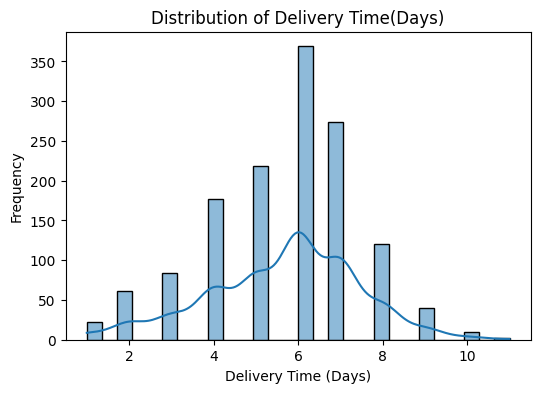

In [67]:
#Distribution of delivery time 
plt.figure(figsize=(6,4))
sns.histplot(df['delivery_time_days'],kde=True)
plt.title('Distribution of Delivery Time(Days)')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Frequency')
plt.show()

In [70]:
#Identify high-cost shipments using threshold
threshold = df['shipping_cost'].quantile(0.90)
df['high_cost_flag']=df['shipping_cost'] > threshold

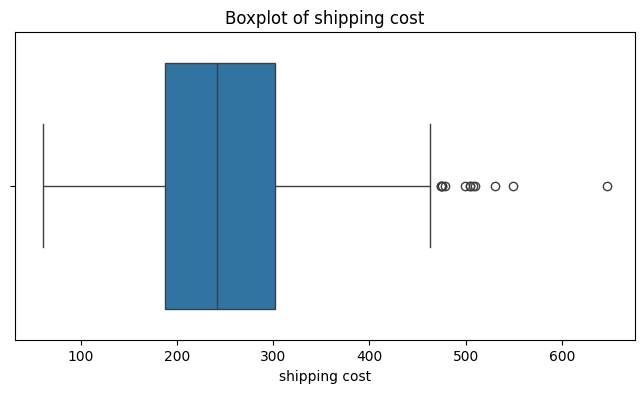

In [71]:
#visualize shipping cost distribution using boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x=df['shipping_cost'])
plt.title('Boxplot of shipping cost')
plt.xlabel('shipping cost')
plt.show()

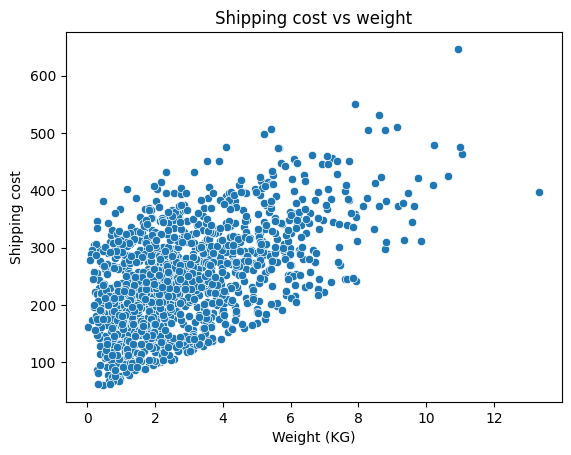

In [21]:
#Analyze the relationship between shipment weight and shipping cost using a scatter plot
sns.scatterplot(x=df['weight_kg'],y=df['shipping_cost'])
plt.title('Shipping cost vs weight')
plt.xlabel('Weight (KG)')
plt.ylabel('Shipping cost')
plt.show()

Q]Perform univariate EDA: distribution plots (hist/KDE) for 3 numeric columns and countplot for 2 categorial columns

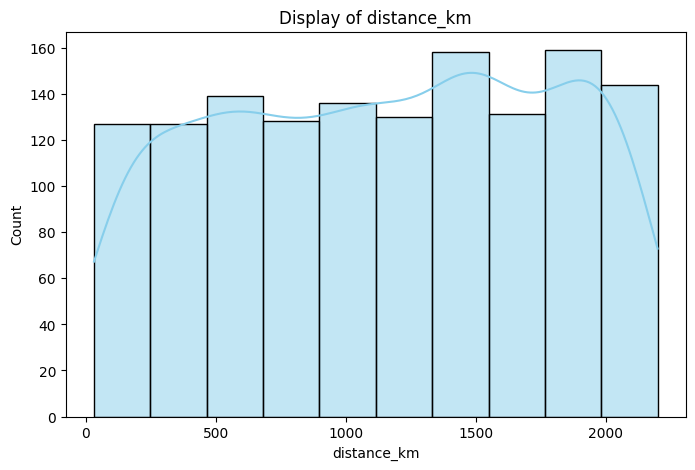

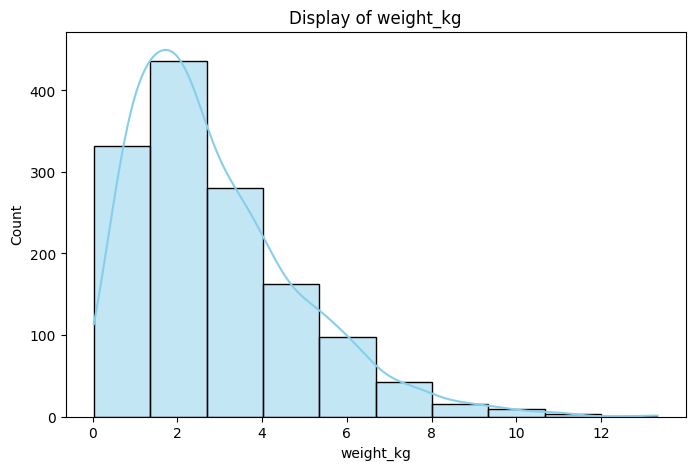

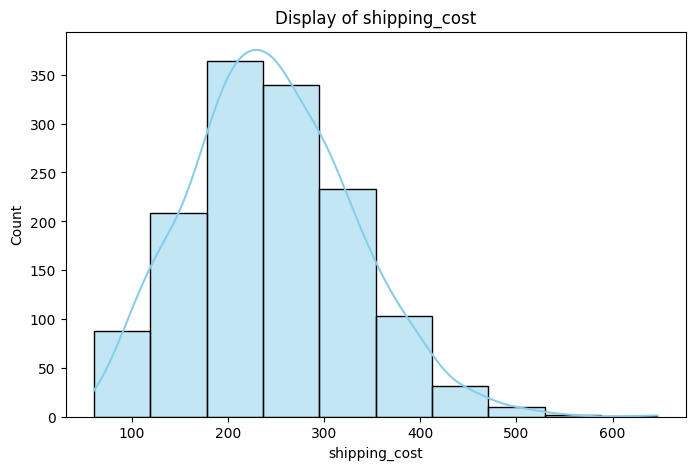

In [74]:
#Visualize distribution of key numerical features
#numeric columns for histogram + KDE
num_col=['distance_km','weight_kg','shipping_cost']
for col in num_col:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col],kde=True,bins=10,color='skyblue')
    plt.title(f'Display of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

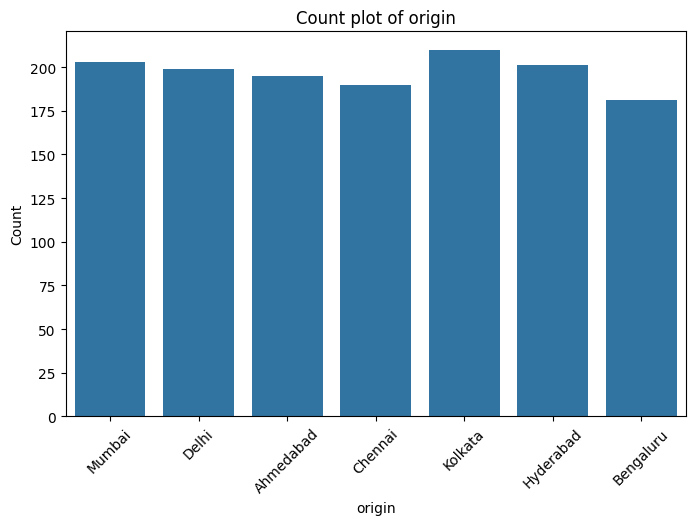

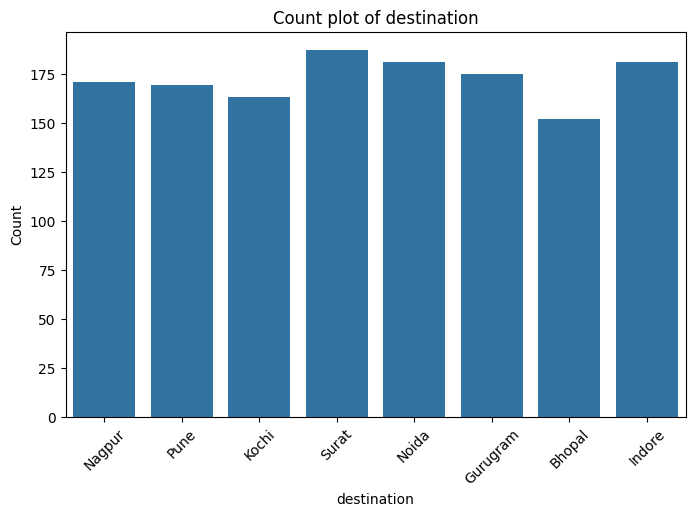

In [76]:
#Visualize distribution of cateorical features
categorial_col=['origin','destination']
#loop through each categorical column
for col in categorial_col:
    plt.figure(figsize=(8,5))
    sns.countplot(x=df[col])
    plt.title(f'Count plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

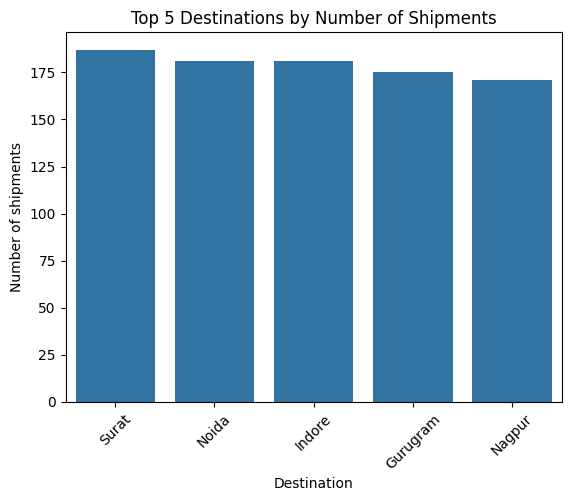

In [77]:
#Visualize top 5 destinations with highest shipment valume
top_dest=df['destination'].value_counts().head()
sns.barplot(x=top_dest.index,y=top_dest.values)
plt.xticks(rotation=45)
plt.title('Top 5 Destinations by Number of Shipments')
plt.xlabel('Destination')
plt.ylabel('Number of shipments')
plt.show()

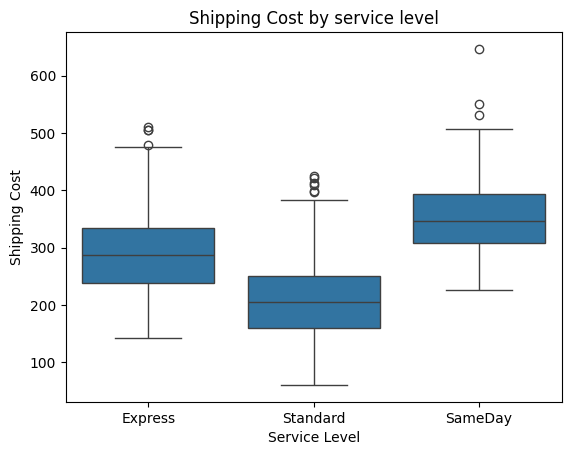

In [79]:
#Compare shipping cost distribution across different service level using a boxplot
sns.boxplot(x='service_level',y='shipping_cost',data=df)
plt.title('Shipping Cost by service level')
plt.xlabel('Service Level')
plt.ylabel('Shipping Cost')
plt.show()

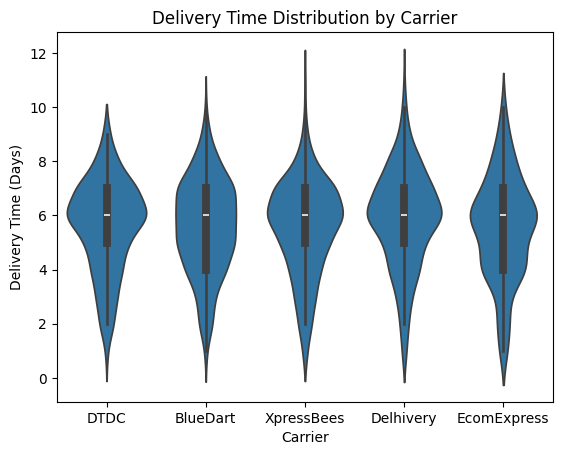

In [80]:
#Visualize distribution of delivery times across service levels using a violin plot
sns.violinplot(x='carrier',y='delivery_time_days',data=df)
plt.title('Delivery Time Distribution by Carrier')
plt.xlabel('Carrier')
plt.ylabel('Delivery Time (Days)')
plt.show()

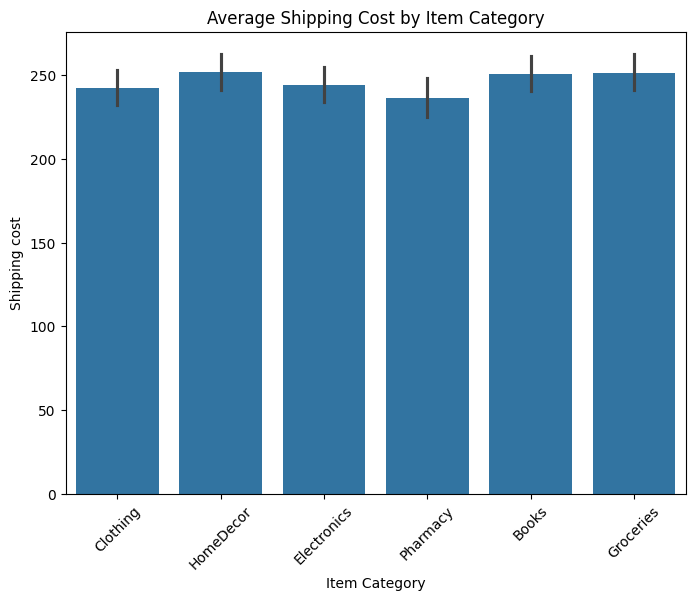

In [81]:
#Compare average shipping cost across item categories
plt.figure(figsize=(8,6))
sns.barplot(x='item_category',y='shipping_cost',data=sampledf)
plt.title('Average Shipping Cost by Item Category')
plt.xlabel('Item Category')
plt.ylabel('Shipping cost')
plt.xticks(rotation=45)
plt.show()

In [28]:
#compute correlation between numeric column to understand relationships between variables
corr_matrix=df.corr(numeric_only=True)
corr_matrix

,distance_km,weight_kg,shipping_cost,damaged_flag,distance_per_kg,delivery_time_days,high_shipping_cost
distance_km,1.000000,-0.039622,0.531612,0.024188,0.256689,0.606332,0.415932
weight_kg,-0.039622,1.000000,0.552115,0.016283,-0.315420,-0.004153,0.412107
shipping_cost,0.531612,0.552115,1.000000,0.045511,-0.030350,0.074055,0.798844
damaged_flag,0.024188,0.016283,0.045511,1.000000,-0.018060,0.017747,0.047286
distance_per_kg,0.256689,-0.315420,-0.030350,-0.018060,1.000000,0.120922,-0.027717
delivery_time_days,0.606332,-0.004153,0.074055,0.017747,0.120922,1.000000,0.037121
high_shipping_cost,0.415932,0.412107,0.798844,0.047286,-0.027717,0.037121,1.000000


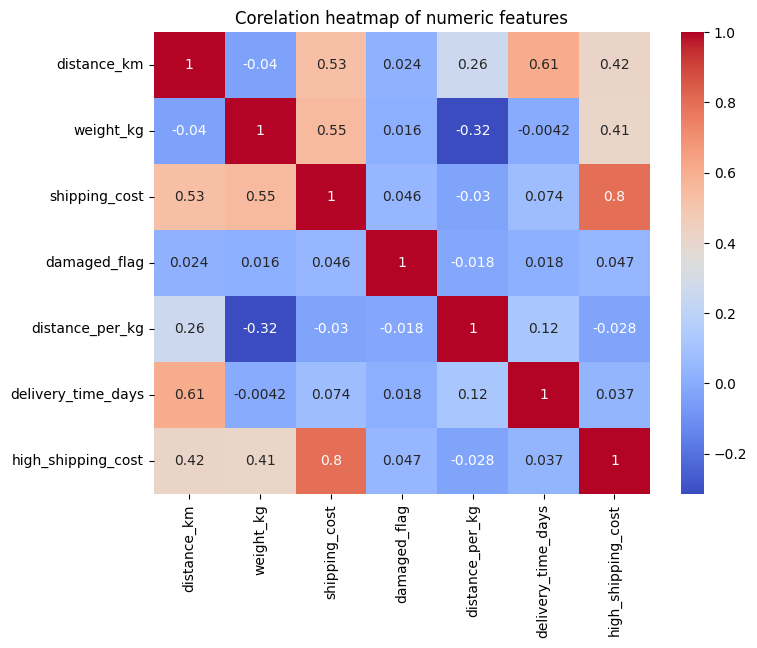

In [29]:
#heatmap
#Create heatmap to analyze correlation between numeric features
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',cbar=True)
plt.title('Corelation heatmap of numeric features')
plt.show()

Q]Find outliers for 2 numeric columns(IQR method)and show impact before vs outlier handling

In [30]:
#Detect outliers using IQR method for shipping_cost
#Detect outliers using IQR method for selected numeric columns.
#Calculate Q1,Q3 and IQR to datetime lower and upper bounds.
#Remove outluers and compare dataset before and after handling.
Q1=df['shipping_cost'].quantile(0.25)
Q3=df['shipping_cost'].quantile(0.75)
IQR = Q3-Q1
lower=Q1 - 1.5*IQR
upper=Q3 + 1.5*IQR

In [31]:
#outer headling
df_clean = df[(df['shipping_cost'] >= lower) & (df['shipping_cost'] <= upper)]

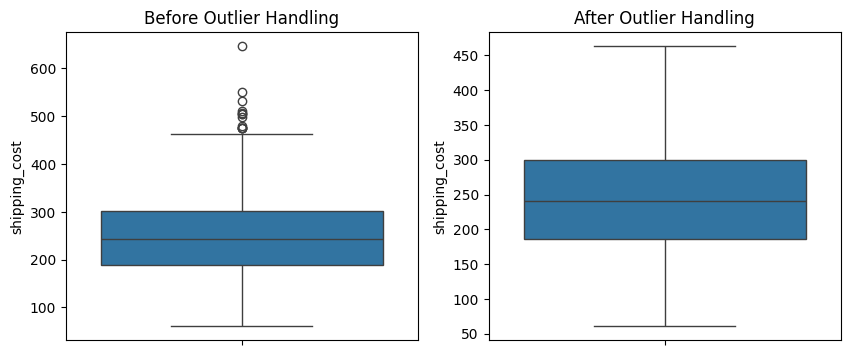

In [32]:
#before vnd after
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(y=df['shipping_cost'])
plt.title('Before Outlier Handling')

plt.subplot(1,2,2)
sns.boxplot(y=df_clean['shipping_cost'])
plt.title('After Outlier Handling')

plt.show()

In [33]:
#Bissiness Question 1 
#Which service level generates the highest total shipping revenue?
#Create a pivot table to calculate total shipping cost (revenue) by service level.
service_revenue = pd.pivot_table(
    df,
    values='shipping_cost',
    index='service_level',
    aggfunc='sum'
).sort_values(by='shipping_cost', ascending=False)
#Sort the values  in descending order to identify top-performing service levels.

service_revenue

,shipping_cost
service_level,
Standard,166388.36
Express,138423.55
SameDay,35324.57


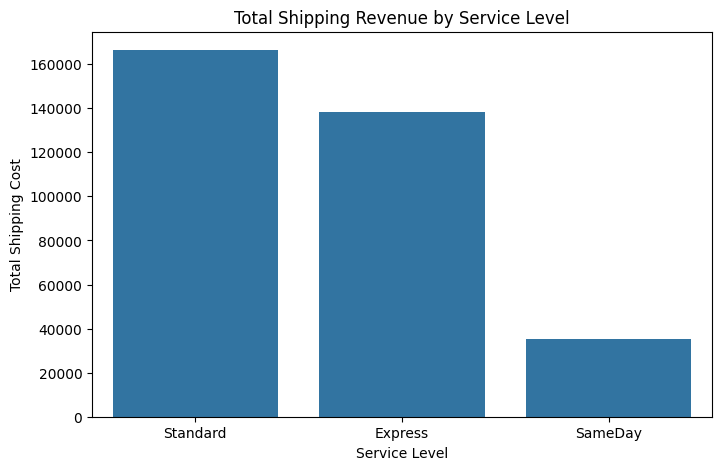

In [34]:
#barplot
#Visualize total shipping revenue by service level using bar chart
plt.figure(figsize=(8,5))
sns.barplot(x=service_revenue.index, y=service_revenue['shipping_cost'])
plt.title("Total Shipping Revenue by Service Level")
plt.xlabel("Service Level")
plt.ylabel("Total Shipping Cost")
plt.show()

In [35]:
#Bissines Question 2 
#Which carrier handles the highest number of shipments?
#Create a pivot table to count total shipments handled by each carrier
carrier_shipments = pd.pivot_table(
    df,
    values='shipment_id',
    index='carrier',
    aggfunc='count'
).sort_values(by='shipment_id', ascending=False)
#sort the values in descending order to identify top carriers.

carrier_shipments

,shipment_id
carrier,
Delhivery,301
XpressBees,297
BlueDart,263
EcomExpress,261
DTDC,257


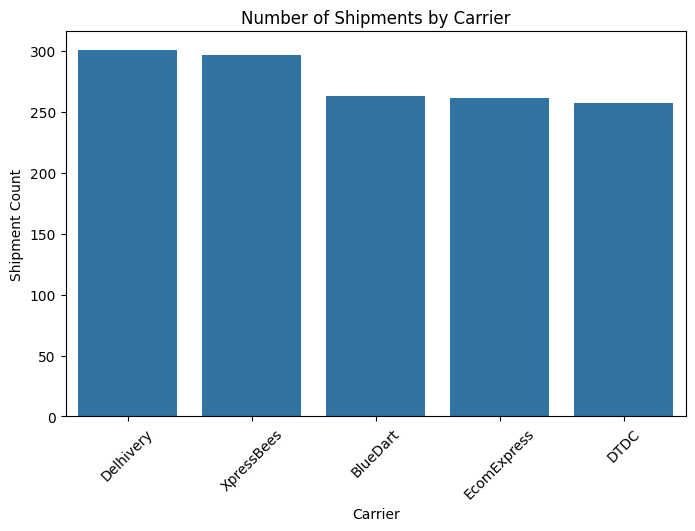

In [36]:
#Visualize number of shipments handled by each carrier using bar chart
plt.figure(figsize=(8,5))

sns.barplot(x=carrier_shipments.index, y=carrier_shipments['shipment_id'])

plt.title("Number of Shipments by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Shipment Count")

plt.xticks(rotation=45)

plt.show()

In [37]:
#Bisiness Question 3 - Average shipping cost by service level
#Which item category has the highest average shipping cost?
#Create a pivot table to calculate average shipping cost for each item category
category_cost = pd.pivot_table(
    df,
    values='shipping_cost',
    index='item_category',
    aggfunc='mean'
).sort_values(by='shipping_cost', ascending=False)
#Sort the values in descending order to identify categories with highest average cost

category_cost

,shipping_cost
item_category,
HomeDecor,252.107686
Groceries,251.435547
Books,250.460664
Electronics,244.319605
Clothing,242.401959
Pharmacy,236.218989


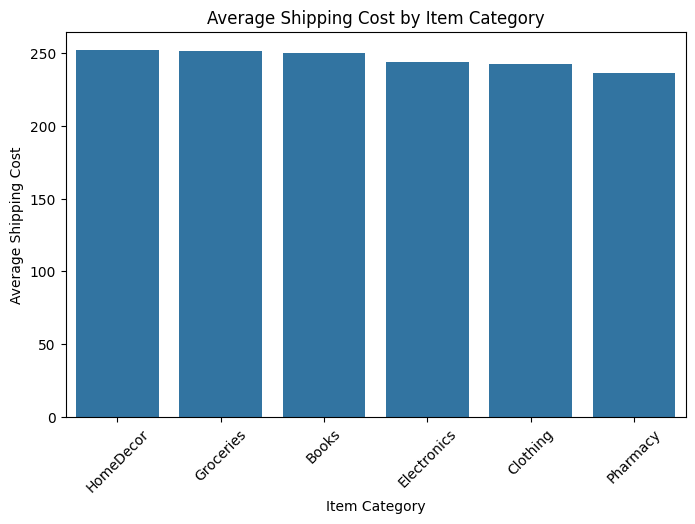

In [38]:
#Visualize average shipping cost by item category using bar chart
plt.figure(figsize=(8,5))

sns.barplot(x=category_cost.index, y=category_cost['shipping_cost'])

plt.title("Average Shipping Cost by Item Category")
plt.xlabel("Item Category")
plt.ylabel("Average Shipping Cost")

plt.xticks(rotation=45)

plt.show()

In [39]:
#bisiness question 4
# Which distance range contributes the most shipments?
#create a bins and labels to categorizedistance into ranges
bins=[0,200,500,1000,2000]
labels=['Short','Medium','Long','Very Long']

#Create new column 'distance_buckt' using pd.cut
df['distance_bucket']=pd.cut(df['distance_km'],bins=bins,labels=labels)

#Create pivot table to cannot number of shipments in each distance range.
distance_analysis = pd.pivot_table(
    df,
    values='shipment_id',
    index='distance_bucket',
    aggfunc='count',
    observed=True
)

distance_analysis

,shipment_id
distance_bucket,
Short,109
Medium,167
Long,303
Very Long,669


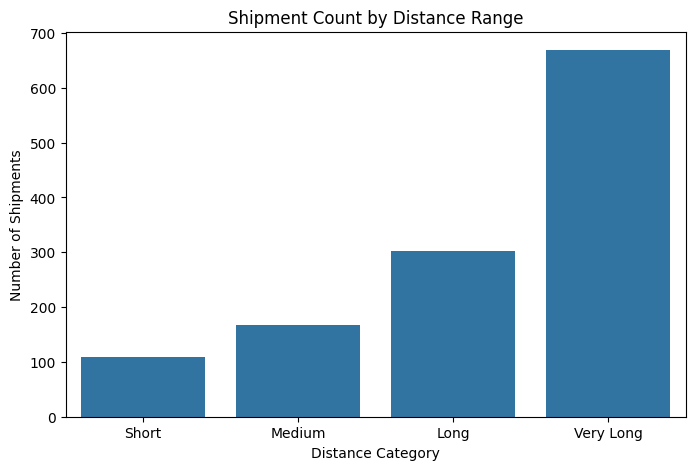

In [40]:
#visualize number of shipments across difference distance range
plt.figure(figsize=(8,5))

sns.barplot(x=distance_analysis.index, y=distance_analysis['shipment_id'])

plt.title("Shipment Count by Distance Range")
plt.xlabel("Distance Category")
plt.ylabel("Number of Shipments")

plt.show()

In [41]:
#Bisiness Question 5 
#Which carrier and service level combination has the highest average shipping cost?
#Create a pivot table to calculate average shipping cost for each carrier and serice level combination
carrier_service = pd.pivot_table(
    df,
    values='shipping_cost',
    index='carrier',
    columns='service_level',
    aggfunc='mean'
)

carrier_service

service_level,Express,SameDay,Standard
carrier,,,
BlueDart,296.396574,356.697619,200.222910
DTDC,290.315761,360.540000,216.065103
Delhivery,301.095542,349.118333,208.885650
EcomExpress,287.853659,340.350741,206.828947
XpressBees,280.258919,396.116923,202.392601


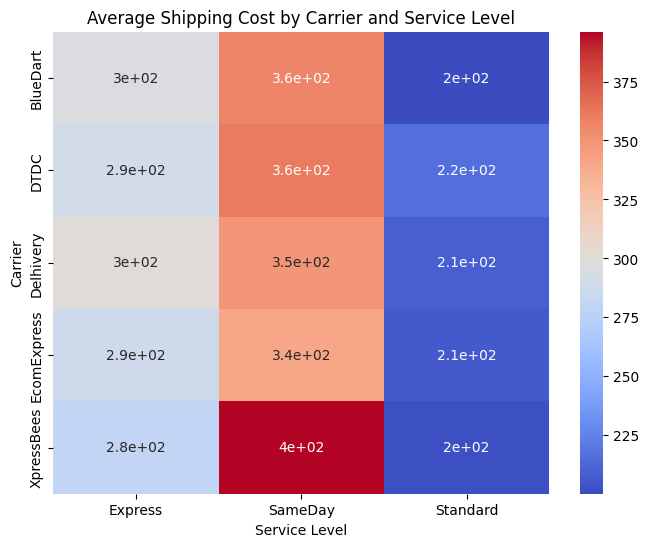

In [42]:
#Visualize average shipping cost using heatmap for carrier and service level combinations
plt.figure(figsize=(8,6))

sns.heatmap(carrier_service, annot=True, cmap='coolwarm')

plt.title("Average Shipping Cost by Carrier and Service Level")

plt.xlabel("Service Level")
plt.ylabel("Carrier")

plt.show()

In [43]:
#Origin wise Daily performance
#Time-Based analysis (daily trend)
#Analyze daily shipping cost trend based on origin.
origin_daily_shippingcost=(
    df.groupby([pd.Grouper(key='ship_date',freq='D'),'origin'])['shipping_cost']
    .sum()
    .reset_index()
)
origin_daily_shippingcost

,ship_date,origin,shipping_cost
0,2024-09-01,Ahmedabad,97.34
1,2024-09-01,Kolkata,348.73
2,2024-09-01,Mumbai,197.48
3,2024-09-02,Delhi,536.04
4,2024-09-02,Kolkata,518.63
...,...,...,...
1116,2025-12-30,Chennai,396.26
1117,2025-12-30,Delhi,366.55
1118,2025-12-31,Bengaluru,312.89
1119,2025-12-31,Chennai,153.12


In [82]:
#Origin wise weekly performance
#Analyze weekly shipping cost trend based on origin
origin_weekly_shippingcost=(
    df.groupby([pd.Grouper(key='ship_date',freq='W'),'origin'])['shipping_cost']
    .sum()
    .reset_index()
)
origin_weekly_shippingcost

,ship_date,origin,shipping_cost
0,2024-09-01,Ahmedabad,97.34
1,2024-09-01,Kolkata,348.73
2,2024-09-01,Mumbai,197.48
3,2024-09-08,Ahmedabad,973.26
4,2024-09-08,Bengaluru,566.19
...,...,...,...
461,2026-01-04,Ahmedabad,244.05
462,2026-01-04,Bengaluru,312.89
463,2026-01-04,Chennai,549.38
464,2026-01-04,Delhi,556.13


In [45]:
#Origin wise monthly performance
#Analyze monthly shipping cost trend based on origin
origin_month_shippingcost=(
    df.groupby([pd.Grouper(key='ship_date',freq='ME'),'origin'])['shipping_cost']
    .sum()
    .reset_index()
)
origin_month_shippingcost

,ship_date,origin,shipping_cost
0,2024-09-30,Ahmedabad,2582.29
1,2024-09-30,Bengaluru,2455.89
2,2024-09-30,Chennai,2616.26
3,2024-09-30,Delhi,5165.22
4,2024-09-30,Hyderabad,1998.11
...,...,...,...
107,2025-12-31,Chennai,2995.81
108,2025-12-31,Delhi,4099.93
109,2025-12-31,Hyderabad,4197.26
110,2025-12-31,Kolkata,2641.29


In [47]:
#Final Report Analysis 1:
#Top Revenue Generating Service Levels
#Analyze total revenue, average cost and shipment cost by serice level
#Group data by service level and calculate key metrics
service_analysis = (
    df.groupby('service_level')
      .agg(total_revenue=('shipping_cost','sum'),
           avg_cost=('shipping_cost','mean'),
           shipment_count=('shipment_id','count'))
      .sort_values('total_revenue',ascending=False)
)
service_analysis

,total_revenue,avg_cost,shipment_count
service_level,,,
Standard,166388.36,206.950697,804
Express,138423.55,290.805777,476
SameDay,35324.57,356.813838,99


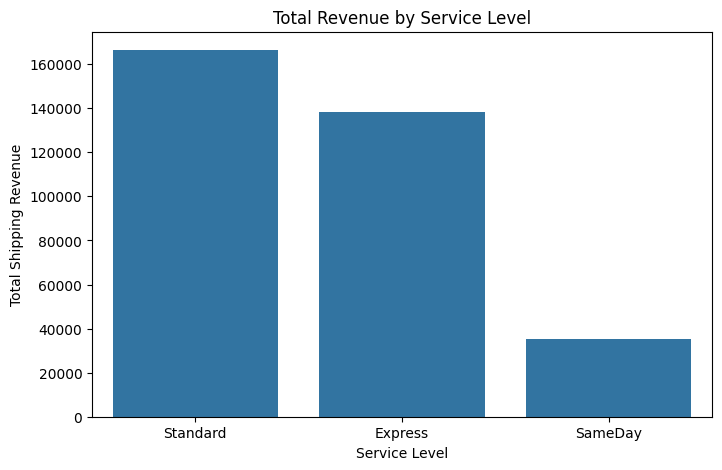

In [48]:
#barplot
#Visualize total revenue generated by each service level
plt.figure(figsize=(8,5))
sns.barplot(
    x=service_analysis.index,
    y=service_analysis['total_revenue']
)

plt.title("Total Revenue by Service Level")
plt.xlabel("Service Level")
plt.ylabel("Total Shipping Revenue")

plt.show()

In [49]:
#Final Report Analysis 2:
#Carrier Market Share
#Calculate market share percentage of each carrier
carrier_market_share = (
    df['carrier']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

carrier_market_share

carrier
Delhivery      21.83
XpressBees     21.54
BlueDart       19.07
EcomExpress    18.93
DTDC           18.64
Name: proportion, dtype: float64

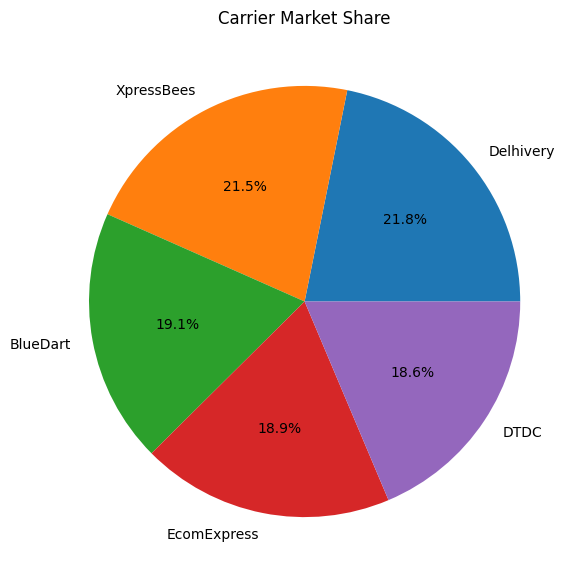

In [50]:
#Visualize market share distribution of carrier using pie chart
plt.figure(figsize=(7,7))

carrier_market_share.plot.pie(autopct='%1.1f%%')

plt.title("Carrier Market Share")

plt.ylabel("")

plt.show()

In [51]:
#Final Report Analysis 3:
#Most Expensive Shipping Routes
#Group data by origin and destination to calculate average shipping cost.
route_cost = (
    df.groupby(['origin','destination'])
      ['shipping_cost']
      .mean()
      .reset_index()
      .nlargest(10,'shipping_cost')
)
route_cost

,origin,destination,shipping_cost
55,Mumbai,Surat,281.667586
9,Bengaluru,Gurugram,277.102400
18,Chennai,Indore,274.400526
12,Bengaluru,Nagpur,272.616818
40,Kolkata,Bhopal,270.985000
11,Bengaluru,Kochi,270.324286
30,Delhi,Pune,270.295517
44,Kolkata,Nagpur,269.976316
25,Delhi,Gurugram,269.674783
42,Kolkata,Indore,266.146552


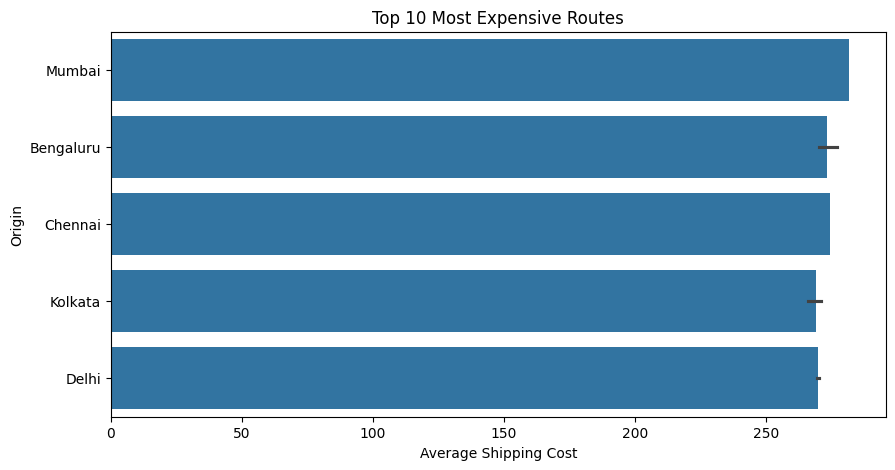

In [52]:
#barplot
#Visualize top 10 most expensive shipping routes using barchart
plt.figure(figsize=(10,5))

sns.barplot(
    x='shipping_cost',
    y='origin',
    data=route_cost
)

plt.title("Top 10 Most Expensive Routes")
plt.xlabel("Average Shipping Cost")
plt.ylabel("Origin")

plt.show()

In [53]:
#Final Report Analysis 4:
#Cost Efficiency by Carrier
#Group data by carrier and calculate average shipping cost and shipment count
carrier_efficiency = (
    df.groupby('carrier')
      .agg(avg_cost=('shipping_cost','mean'),
           total_shipments=('shipment_id','count'))
      .assign(cost_rank=lambda x: x['avg_cost'].rank())  #Rank carriers based on average cost(lower cost = better efficiency)
      .sort_values('avg_cost')
)

carrier_efficiency

,avg_cost,total_shipments,cost_rank
carrier,,,
XpressBees,239.973670,297,1.0
Delhivery,242.698306,301,2.0
EcomExpress,246.097586,261,3.0
BlueDart,252.210456,263,4.0
DTDC,253.888288,257,5.0


In [55]:
#Final Report Analyis 5:
#Distance Bucket comparison
#Create distance buckets using bins and labels
bins=[0,200,500,1000,2000]
labels=['Short','Medium','Long','Very Long']
df['distance_bucket']=pd.cut(df['distance_km'],bins=bins,labels=labels)

distance_analysis=(
    df.groupby('distance_bucket',observed=True)
    .agg(
        shipments=('shipment_id','count'),
        avg_cost=('shipping_cost','mean')
    )
)
distance_analysis

,shipments,avg_cost
distance_bucket,,
Short,109,165.423853
Medium,167,196.984671
Long,303,217.939835
Very Long,669,270.308401


In [57]:
#create deliver delay column (actual delivery date - promised delivery)
df['delivery_delay_days']=(df['delivered_date'] - df['promised_date']).dt.days
#check first few rows to veryfy new column
df.head()

,shipment_id,ship_date,origin,destination,carrier,service_level,item_category,distance_km,weight_kg,promised_date,delivered_date,shipping_cost,damaged_flag,distance_per_kg,delivery_time_days,high_shipping_cost,distance_bucket,delivery_delay_days
0,SHP500000,2025-08-16,Mumbai,Nagpur,DTDC,Express,Clothing,1393.2,2.00,2025-08-21,2025-08-21,291.46,0,696.600000,5,True,Very Long,0
2,SHP500002,2025-07-24,Delhi,Pune,BlueDart,Standard,HomeDecor,623.4,4.37,2025-07-28,2025-07-29,199.12,0,142.654462,5,False,Long,1
3,SHP500003,2025-03-27,Ahmedabad,Kochi,XpressBees,Standard,Electronics,160.8,3.10,2025-03-29,2025-03-29,130.36,0,51.870968,2,False,Short,0
4,SHP500004,2025-11-01,Chennai,Surat,BlueDart,Standard,Pharmacy,1767.9,4.26,2025-11-07,2025-11-10,287.93,0,415.000000,9,True,Very Long,3
5,SHP500005,2024-10-23,Ahmedabad,Noida,XpressBees,Express,Books,295.1,2.48,2024-10-26,2024-10-26,215.61,0,118.991935,3,False,Medium,0


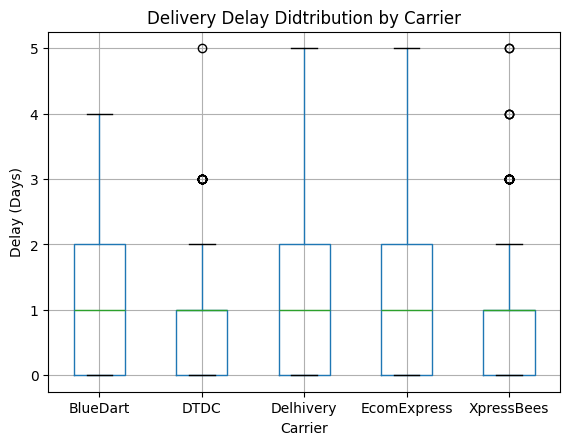

In [58]:
#Visualize delay distribution by carrier 
df.boxplot(column='delivery_delay_days',by='carrier')
plt.title('Delivery Delay Didtribution by Carrier')
plt.suptitle("")
plt.xlabel('Carrier')
plt.ylabel('Delay (Days)')
plt.show()

In [59]:
#Analyz delivery delay by carrier
carrier_delay= df.groupby('carrier')['delivery_delay_days'].agg(
    avg_delay='mean',
    median_delay='median',
    max_delay= 'max',
    min_delay= 'min',
    count_shipment = 'count'
).sort_values(by='avg_delay', ascending=False)
carrier_delay

,avg_delay,median_delay,max_delay,min_delay,count_shipment
carrier,,,,,
Delhivery,1.039867,1.0,5,0,301
BlueDart,0.954373,1.0,4,0,263
XpressBees,0.946128,1.0,5,0,297
EcomExpress,0.911877,1.0,5,0,261
DTDC,0.906615,1.0,5,0,257


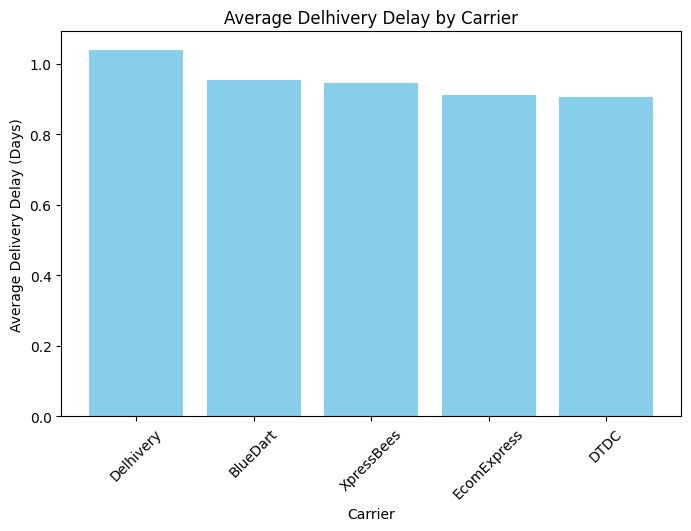

In [60]:
#Bar plot
#Average delay per carrier
carrier_avg=df.groupby('carrier')['delivery_delay_days'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
plt.bar(carrier_avg.index,carrier_avg.values,color='skyblue')
plt.xlabel('Carrier')
plt.ylabel('Average Delivery Delay (Days)')
plt.title('Average Delhivery Delay by Carrier')
plt.xticks(rotation=45)
plt.show()

In [61]:
#Analyse delivery delay by service level
service_delay= df.groupby('service_level')['delivery_delay_days'].agg(
    avg_delay='mean',
    meadin_delay='median',
    max_delay='max',
    count_delay='count'
).sort_values(by='avg_delay',ascending=False)
service_delay

,avg_delay,meadin_delay,max_delay,count_delay
service_level,,,,
Standard,1.019900,1.0,5,804
Express,0.978992,1.0,5,476
SameDay,0.303030,0.0,3,99


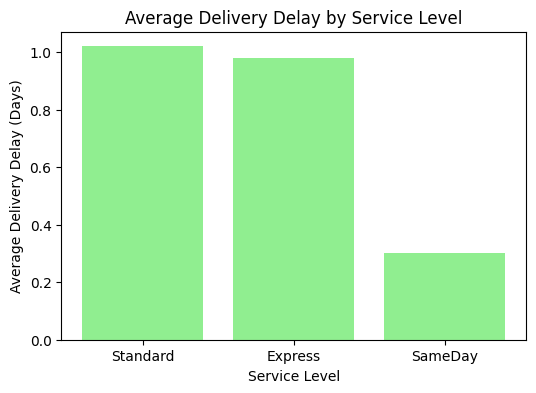

In [62]:
#average delay per service level 
service_avg = df.groupby('service_level')['delivery_delay_days'].mean().sort_values(ascending=False)
plt.figure(figsize=(6,4))
plt.bar(service_avg.index,service_avg.values,color='lightgreen')
plt.xlabel('Service Level')
plt.ylabel('Average Delivery Delay (Days)')
plt.title('Average Delivery Delay by Service Level')
plt.show()

In [63]:
#Extract year/month from promised date for monthly aggregation
df['year_month']=df['promised_date'].dt.to_period('M')

In [64]:
#Create on time delivery flag (1=delivered on time, 0= delayed)
df['on_time']=(df['delivered_date'] <= df['promised_date']).astype(int)
df.head()

,shipment_id,ship_date,origin,destination,carrier,service_level,item_category,distance_km,weight_kg,promised_date,delivered_date,shipping_cost,damaged_flag,distance_per_kg,delivery_time_days,high_shipping_cost,distance_bucket,delivery_delay_days,year_month,on_time
0,SHP500000,2025-08-16,Mumbai,Nagpur,DTDC,Express,Clothing,1393.2,2.00,2025-08-21,2025-08-21,291.46,0,696.600000,5,True,Very Long,0,2025-08,1
2,SHP500002,2025-07-24,Delhi,Pune,BlueDart,Standard,HomeDecor,623.4,4.37,2025-07-28,2025-07-29,199.12,0,142.654462,5,False,Long,1,2025-07,0
3,SHP500003,2025-03-27,Ahmedabad,Kochi,XpressBees,Standard,Electronics,160.8,3.10,2025-03-29,2025-03-29,130.36,0,51.870968,2,False,Short,0,2025-03,1
4,SHP500004,2025-11-01,Chennai,Surat,BlueDart,Standard,Pharmacy,1767.9,4.26,2025-11-07,2025-11-10,287.93,0,415.000000,9,True,Very Long,3,2025-11,0
5,SHP500005,2024-10-23,Ahmedabad,Noida,XpressBees,Express,Books,295.1,2.48,2024-10-26,2024-10-26,215.61,0,118.991935,3,False,Medium,0,2024-10,1


In [65]:
#Calculate percentage on-time delivery by carrier and month
#groupby year_month and carrier
sla_report=df.groupby(['year_month','carrier']).agg(
    total_shipment=('shipment_id','count'),
    on_time_shipments=('on_time','sum')
).reset_index()

#calculate on time delivery percentage 
sla_report['on_time_pct'] = (sla_report['on_time_shipments']/sla_report['total_shipment']) * 100

sla_report

,year_month,carrier,total_shipment,on_time_shipments,on_time_pct
0,2024-09,BlueDart,11,3,27.272727
1,2024-09,DTDC,15,4,26.666667
2,2024-09,Delhivery,15,5,33.333333
3,2024-09,EcomExpress,11,5,45.454545
4,2024-09,XpressBees,19,6,31.578947
...,...,...,...,...,...
80,2026-01,BlueDart,2,1,50.000000
81,2026-01,DTDC,5,2,40.000000
82,2026-01,Delhivery,3,0,0.000000
83,2026-01,EcomExpress,3,1,33.333333


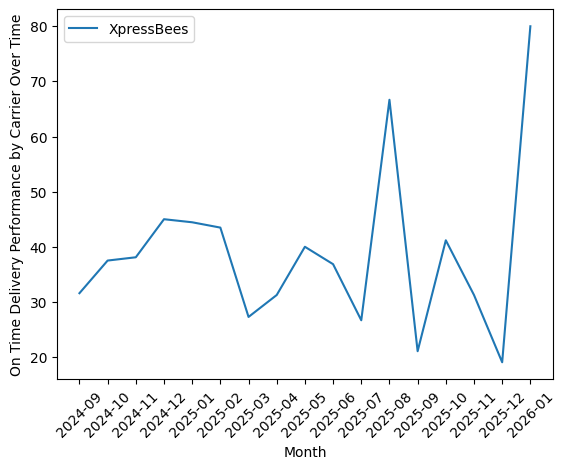

In [66]:
#Visualize monthly on time delivery percentage for each carrier using line plot
for carrier in sla_report['carrier'].unique():
    data=sla_report[sla_report['carrier']==carrier]

plt.plot(data['year_month'].astype(str),data['on_time_pct'],label=carrier)
plt.xlabel('Month')
plt.ylabel('On Time Delivery Performance by Carrier Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.show()